In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
# def inv_softplus(y: jax.Array) -> jax.Array:
#     return jnp.log(jnp.expm1(y))


# class MLP(eqx.Module):
#     layer1: eqx.nn.Linear
#     layer2: eqx.nn.Linear

#     def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
#         key1, key2 = jax.random.split(key)
#         self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
#         self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

#         self.layer1 = eqx.tree_at(
#             lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
#         )
#         self.layer2 = eqx.tree_at(
#             lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
#         )

#     def __call__(self, x: jax.Array) -> jax.Array:
#         x = jnp.ravel(x)
#         x = jax.nn.tanh(self.layer1(x))
#         x = self.layer2(x)
#         return x   # shape (3,)
    

# class Example(TripletModel):
#     # internal unconstrained parameters for a 2x2 lower-triangular factor
#     # not the physical [k_ss, k_sb, k_bb] directly
#     K: jax.Array
#     mlp: MLP

#     def __init__(self, der_K: jax.Array, key: jax.Array):
#         """
#         der_K is the user-facing 3-vector:
#             [diag_stretching, offdiag_stretch_bend, diag_bending]
#           = [k_ss, k_sb, k_bb]

#         This is converted internally to parameters of a Cholesky factor so that
#         the resulting stiffness is symmetric PSD.
#         """
#         der_K = jnp.ravel(der_K)
#         if der_K.shape != (3,):
#             raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

#         k_ss0, k_sb0, k_bb0 = der_K
#         eps = 1e-6

#         # PSD check for the structured matrix
#         # In the symmetric-stretch / bending basis, the 2x2 block is:
#         # [[k_ss, sqrt(2) k_sb],
#         #  [sqrt(2) k_sb, k_bb]]
#         #
#         # So PSD requires:
#         #   k_ss >= 0
#         #   k_bb >= 0
#         #   k_ss * k_bb - 2 * k_sb^2 >= 0
#         if (k_ss0 < 0) or (k_bb0 < 0) or (k_ss0 * k_bb0 - 2.0 * k_sb0**2 < 0):
#             raise ValueError(
#                 "Initial [k_ss, k_sb, k_bb] must satisfy PSD condition: "
#                 "k_ss >= 0, k_bb >= 0, and k_ss*k_bb - 2*k_sb^2 >= 0."
#             )

#         # Convert desired physical entries to a 2x2 Cholesky factor
#         l11 = jnp.sqrt(jnp.maximum(k_ss0, eps))
#         l21 = jnp.sqrt(2.0) * k_sb0 / l11
#         rem = k_bb0 - l21**2
#         l22 = jnp.sqrt(jnp.maximum(rem, eps))

#         # Store unconstrained parameters so diagonals can be enforced positive via softplus
#         p0 = inv_softplus(l11 - eps)
#         p1 = l21
#         p2 = inv_softplus(l22 - eps)

#         self.K = jnp.array([p0, p1, p2])
#         self.mlp = MLP(in_features=5, hidden_size=10, out_features=3, key=key)

#     def _vec_to_L(self, p: jax.Array) -> jax.Array:
#         eps = 1e-6
#         p = jnp.ravel(p)
#         return jnp.array([
#             [jax.nn.softplus(p[0]) + eps, 0.0],
#             [p[1],                        jax.nn.softplus(p[2]) + eps],
#         ])

#     def get_K_entries(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3"]:
#         """
#         Returns the physical structured coefficients:
#             [k_ss, k_sb, k_bb]
#         where the energy is

#             0.5*k_ss*(e0^2 + e1^2) + k_sb*(e0 + e1)*eb + 0.5*k_bb*eb^2
#         """
#         del_strain = jnp.ravel(del_strain)

#         # small learned correction in parameter space for stability
#         dp = 1e-2 * self.mlp(del_strain)
#         p = self.K + dp

#         L = self._vec_to_L(p)
#         B = L @ L.T
#         # B is the PSD 2x2 block in [symmetric-stretch, bending] basis:
#         # B = [[k_ss, sqrt(2) k_sb],
#         #      [sqrt(2) k_sb, k_bb]]

#         k_ss = B[0, 0]
#         k_sb = B[0, 1] / jnp.sqrt(2.0)
#         k_bb = B[1, 1]

#         return jnp.array([k_ss, k_sb, k_bb])

#     def get_K_matrix(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3 3"]:
#         """
#         Full structured stiffness matrix acting on [e0, e1, eb]:
#             [[k_ss,   0,   k_sb],
#              [  0,  k_ss,  k_sb],
#              [k_sb, k_sb,  k_bb]]
#         """
#         k_ss, k_sb, k_bb = self.get_K_entries(del_strain)
#         return jnp.array([
#             [k_ss, 0.0,  k_sb],
#             [0.0,  k_ss, k_sb],
#             [k_sb, k_sb, k_bb],
#         ])

#     def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
#         del_strain = jnp.ravel(del_strain)

#         e0 = del_strain[0]
#         e1 = del_strain[1]
#         eb = del_strain[3]

#         k_ss, k_sb, k_bb = self.get_K_entries(del_strain)

#         stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
#         coupling_energy = k_sb * (e0 + e1) * eb
#         bending_energy = 0.5 * k_bb * eb**2

#         return stretching_energy + coupling_energy + bending_energy

In [3]:
def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jnp.ravel(x)
        x = jax.nn.tanh(self.layer1(x))
        x = self.layer2(x)
        return x   # shape (3,)
    

class Example(TripletModel):
    # internal unconstrained parameters for a 2x2 lower-triangular factor
    # not the physical [k_ss, k_sb, k_bb] directly
    K: jax.Array
    mlp: MLP
    l_k: float # physcially voronoi length scale

    def __init__(self, der_K: jax.Array, key: jax.Array, l_k: float = 0.25):
        """
        der_K is the user-facing 3-vector:
            [diag_stretching, offdiag_stretch_bend, diag_bending]
          = [k_ss, k_sb, k_bb]

        This is converted internally to parameters of a Cholesky factor so that
        the resulting stiffness is symmetric PSD.
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # PSD check for the structured matrix
        # In the symmetric-stretch / bending basis, the 2x2 block is:
        # [[k_ss, sqrt(2) k_sb],
        #  [sqrt(2) k_sb, k_bb]]
        #
        # So PSD requires:
        #   k_ss >= 0
        #   k_bb >= 0
        #   k_ss * k_bb - 2 * k_sb^2 >= 0
        if (k_ss0 < 0) or (k_bb0 < 0) or (k_ss0 * k_bb0 - 2.0 * k_sb0**2 < 0):
            raise ValueError(
                "Initial [k_ss, k_sb, k_bb] must satisfy PSD condition: "
                "k_ss >= 0, k_bb >= 0, and k_ss*k_bb - 2*k_sb^2 >= 0."
            )

        # Convert desired physical entries to a 2x2 Cholesky factor
        l11 = jnp.sqrt(jnp.maximum(k_ss0, eps))
        l21 = jnp.sqrt(2.0) * k_sb0 / l11
        rem = k_bb0 - l21**2
        l22 = jnp.sqrt(jnp.maximum(rem, eps))

        # Store unconstrained parameters so diagonals can be enforced positive via softplus
        p0 = inv_softplus(l11 - eps)
        p1 = l21
        p2 = inv_softplus(l22 - eps)

        self.K = jnp.array([p0, p1, p2])
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=3, key=key)
        self.l_k = l_k

    def _vec_to_L(self, p: jax.Array) -> jax.Array:
        eps = 1e-6
        p = jnp.ravel(p)
        return jnp.array([
            [jax.nn.softplus(p[0]) + eps, 0.0],
            [p[1],                        jax.nn.softplus(p[2]) + eps],
        ])

    def get_K_entries_base(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3"]:
        """
        Returns the physical structured coefficients:
            [k_ss, k_sb, k_bb]
        where the energy is

            0.5*k_ss*(e0^2 + e1^2) + k_sb*(e0 + e1)*eb + 0.5*k_bb*eb^2
        """
        del_strain = jnp.ravel(del_strain)

        # small learned correction in parameter space for stability
        dp = 1e-2 * self.mlp(del_strain)
        p = self.K + dp

        L = self._vec_to_L(p)
        B = L @ L.T
        # B is the PSD 2x2 block in [symmetric-stretch, bending] basis:
        # B = [[k_ss, sqrt(2) k_sb],
        #      [sqrt(2) k_sb, k_bb]]

        k_ss = B[0, 0]
        k_sb = B[0, 1] / jnp.sqrt(2.0)
        k_bb = B[1, 1]

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_entries(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3"]:
        k_ss_base, k_sb_base, k_bb_base = self.get_K_entries_base(del_strain)

        k_ss = self.l_k * k_ss_base
        k_bb = k_bb_base / self.l_k
        k_sb = k_sb_base

        return jnp.array([k_ss, k_sb, k_bb])
    
    def get_K_matrix(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, "3 3"]:
        """
        Full structured stiffness matrix acting on [e0, e1, eb]:
            [[k_ss,   0,   k_sb],
             [  0,  k_ss,  k_sb],
             [k_sb, k_sb,  k_bb]]
        """
        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])
    
    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

In [4]:
from util import TestCase

# train_file = "output.npz"
# valid_file = "output_valid.npz"

train_file = "data/combined_output_train.npz"
valid_file = "data/combined_output_valid.npz"

init_K=jnp.array([0.2, 0.0, 0.02])
validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=5000, lr=5e-2, init_K=init_K )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.get_K_entries(jnp.zeros(5)) )

lk:  0.25
EA:  196.34954084936206
EI1:  0.019634954084936207
EI2:  0.019634954084936207
GJ:  0.019634954084936207
xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]
xb_c:  [0.  0.  0.  0.  0.  0.5 0.  0. ]


/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: data/combined_output_train.npz: expected xb_c to have shape (n_traj, n_b), got shape (2, 8). Using same xb_c for all trajectories.
  warnings.warn(
/Users/radha/GitRepos/dismech-jax/examples/slinky/util_multiset.py:50: UserWarning: data/combined_output_valid.npz: expected xb_c to have shape (n_traj, n_b), got shape (2, 8). Using same xb_c for all trajectories.
  warnings.warn(


Step 0    | LR: 5.000e-02  | Train: 8.27321e-02  | Valid: 1.29151e-02  | K: [0.06543206 0.01665304 0.08217227]
Step 10   | LR: 5.000e-02  | Train: 1.29151e-03  | Valid: 3.10260e-04  | K: [0.19948939 0.14097541 0.26157123]
Step 20   | LR: 5.000e-02  | Train: 6.70918e-04  | Valid: 4.52830e-04  | K: [0.2836967  0.2027266  0.35121105]
Step 30   | LR: 5.000e-02  | Train: 6.96951e-04  | Valid: 5.36614e-04  | K: [0.32645607 0.22760195 0.37775156]
Step 40   | LR: 4.999e-02  | Train: 7.08040e-04  | Valid: 5.44759e-04  | K: [0.34470794 0.2328479  0.37339839]
Step 50   | LR: 4.999e-02  | Train: 6.83782e-04  | Valid: 5.11806e-04  | K: [0.35047737 0.22817171 0.35399976]
Step 60   | LR: 4.998e-02  | Train: 6.38412e-04  | Valid: 4.54236e-04  | K: [0.35016756 0.2183998  0.32714609]
Step 70   | LR: 4.998e-02  | Train: 5.81146e-04  | Valid: 3.78912e-04  | K: [0.34754638 0.20653542 0.29785406]
Step 80   | LR: 4.997e-02  | Train: 5.22666e-04  | Valid: 2.99710e-04  | K: [0.34600184 0.19557991 0.2712614 ]
S

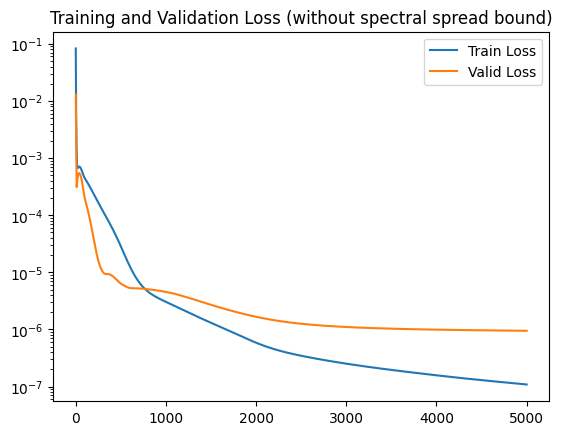

In [5]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.title("Training and Validation Loss (without spectral spread bound)")
plt.legend()
plt.show()

In [6]:
train = TestCase.from_npz(train_file)
valid = TestCase.from_npz(valid_file)
# train = TestCase.from_npz("output_valid.npz")
# valid = TestCase.from_npz("output_valid.npz")
print("Train:")
print("fixed idx:", train.bc.idx_b)
print("slope:", train.bc.xb_m)
print("intercept:", train.bc.xb_c)
print("Valid:")
print("fixed idx:", valid.bc.idx_b)
print("slope:", valid.bc.xb_m)
print("intercept:", valid.bc.xb_c)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])


Train:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.   0.   0.   0.   0.  -0.4  0.   0. ]]

 [[ 0.   0.   0.   0.   0.   1.5  0.   0. ]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]
Valid:
fixed idx: [ 0  1  2  3  7  8  9 10]
slope: [[[ 0.   0.   0.   0.   0.  -0.2  0.   0.1]]

 [[ 0.   0.   0.   0.   0.   0.5  0.  -0.1]]]
intercept: [0.  0.  0.  0.  0.  0.5 0.  0. ]


In [7]:

print(valid.bc)
base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
print("Base rod: ", base)
print("Rods: ", rods)
pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print(pred)
print(pred.shape)
print(valid.qs.shape)
print(train.qs.shape)
# animate(pred)

BatchedLinearBC(idx_b=i64[8](numpy), xb_m=f64[2,1,8](numpy), xb_c=f64[8](numpy))
lk:  0.25
EA:  196.34954084936206
EI1:  0.019634954084936207
EI2:  0.019634954084936207
GJ:  0.019634954084936207
Base rod:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=AbstractBC()
)
Rods:  Rod(
  triplets=Triplet(bar_strain=f64[1,5], l_k=f64[1,2]),
  mass=f64[11],
  q0=f64[11],
  E_ext=Gravity(F_ext=f64[11]),
  bc=BatchedLinearBC(
    idx_b=i64[8](numpy), xb_m=f64[2,1,8](numpy), xb_c=f64[8](numpy)
  )
)
[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.50002625e-01  5.58793586e-07 -1.70695903e-01  0.00000000e+00
    5.00000000e-01  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    2.40845377e-01  1.66468868e-06 -1.66656875e-01  0.00000000e+00
    4.80000000e-01  0.00000000e+00  1.00000000e-02]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.0

In [8]:
# animate(valid.qs)

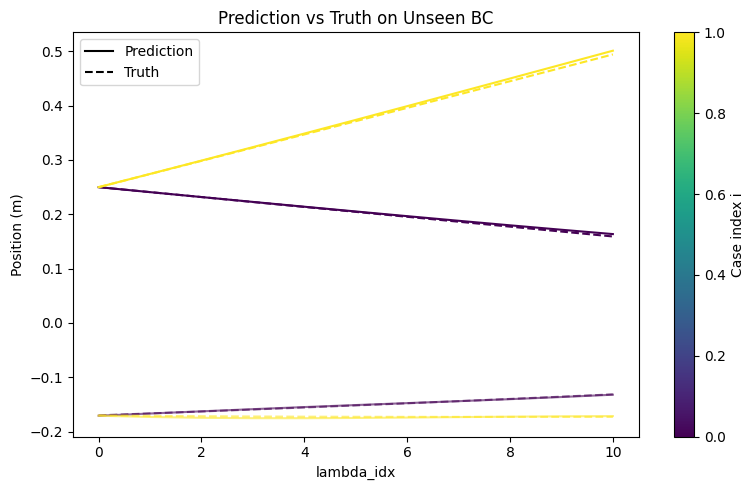

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()

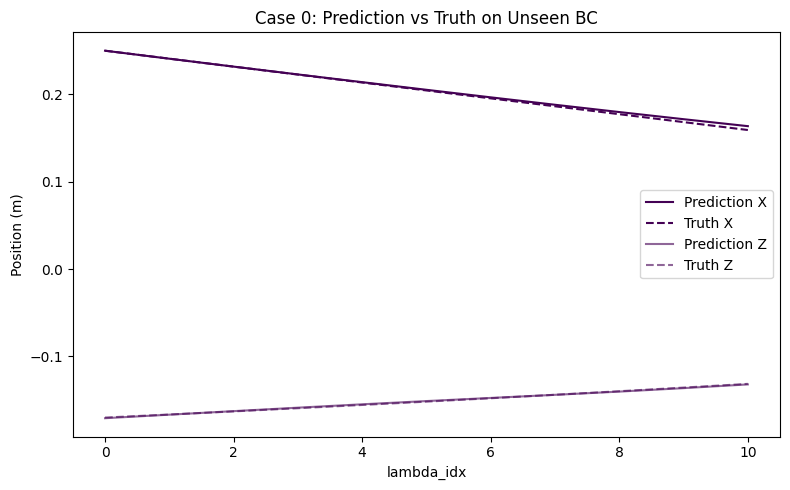

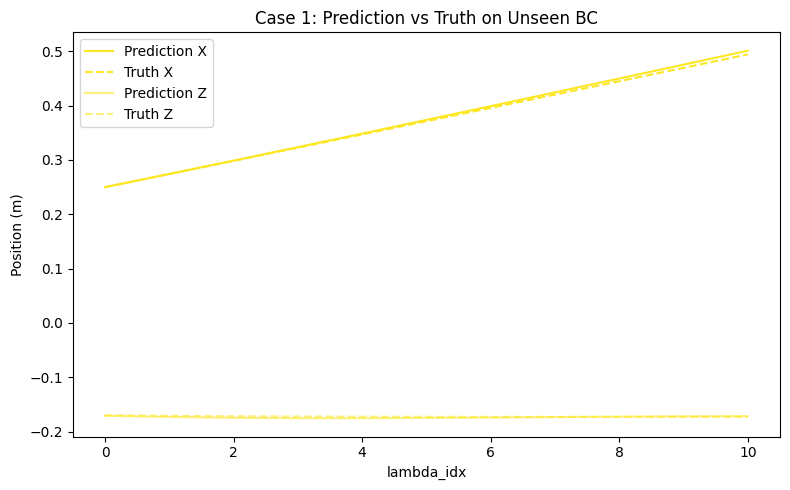

In [10]:
# create separate plots for all 5 cases for X and Z, with predicted and true on the same plot, and color by case index
for i in range(n_cases):
    c = colors[i]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(pred[i, :, 4], color=c, linestyle='-', label='Prediction X')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--', label='Truth X')
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6, label='Prediction Z')
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6, label='Truth Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.00157272e-02  6.23413092e-06 -1.87967656e-01  0.00000000e+00
   1.80000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   7.00164065e-02  5.87594802e-06 -1.89122811e-01  0.00000000e+00
   1.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.00171415e-02  5.53160840e-06 -1.90022059e-01  0.00000000e+00
   1.00000000e-01  0.00000000e+00  0.00000000e+00]]
final:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   8.50000004e-01  3.73486080e-07 -5.47967535e-02  0.00000000e+00
   1.70000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   9.24999861e-01 -3.54024268e-07 -3.84803710e-02  0.00000000e+00
   1.85000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.000

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.70012905e-01  7.72776659e-06 -1.80809173e-01  0.00000000e+00
   3.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.50013600e-01  7.33135081e-06 -1.82970911e-01  0.00000000e+00
   3.00000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.30014331e-01  6.96380666e-06 -1.84888700e-01  0.00000000e+00
   2.60000000e-01  0.00000000e+00  0.00000000e+00]]
final position of the middle node in the training data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   5.49999451e-01 -8.45845735e-06 -1.14145036e-01  0.00000000e+00
   1.10000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   6.24999659e-01 -6.23204214e-06 -9.96319008e-02  0.00000000e+00
   1.25000000e+00  

In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.13578310e-01 -3.93045419e-05 -1.55548195e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00  4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.04503547e-01 -5.37021584e-05 -1.51743620e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00  5.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.95437797e-01 -6.93358761e-05 -1.47852327e-01  0.00000000e+00
   3.80000000e-01  0.00000000e+00  6.00000000e-02]]
final position of the middle node in the validation data:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.47015258e-01  1.46491388e-05 -1.72472247e-01  0.00000000e+00
   7.00000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.71425859e-01  1.85378674e-05 -1.72679838e-01  0.00000000e+00
   7.50000000e-

In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.13992932e-01  6.36514022e-06 -1.54777115e-01  0.00000000e+00
   4.20000000e-01  0.00000000e+00  4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   2.05251749e-01  7.96794451e-06 -1.51074170e-01  0.00000000e+00
   4.00000000e-01  0.00000000e+00  5.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.96621640e-01  9.26813230e-06 -1.47494616e-01  0.00000000e+00
   3.80000000e-01  0.00000000e+00  6.00000000e-02]]
final position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.48652492e-01 -5.85768452e-06 -1.75275292e-01  0.00000000e+00
   7.00000000e-01  0.00000000e+00 -4.00000000e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   3.73799249e-01 -6.63036761e-06 -1.74821722e-01  0.00000000e+00
   7.50000000e-01  0.0000